# LLaMA 3.1-8B — Arabic Document Sensitivity Classification
**Multi-shot evaluation** (Zero / One / Three-Shot) using the **base LLaMA 3.1-8B-Instruct** model (no fine-tuning).
Classification follows **NDMO/SDAIA** sensitivity levels: عام · مقيد · سري · سري للغاية

## 0. Setup

In [1]:
# Install all required libraries
!pip install -q -U transformers accelerate bitsandbytes datasets \
                   scikit-learn seaborn matplotlib pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 135.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 157.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 142.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 52.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requ

In [2]:
# ── Imports ──────────────────────────────────────────────
import os, torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import drive, userdata
from huggingface_hub import login
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)


In [3]:
# ── Mount Drive & Authenticate ───────────────────────────
if not os.path.ismount("/content/drive"):
    drive.mount("/content/drive")

login(token=userdata.get("HF_TOKEN"))


Mounted at /content/drive


In [4]:
# ── Paths & Global Constants ─────────────────────────────
BASE_MODEL_ID  = "meta-llama/Meta-Llama-3.1-8B-Instruct"
TEST_DATA_PATH = "/content/drive/MyDrive/Project/locked_test_dataset.csv"
RESULTS_DIR    = "/content/drive/MyDrive/llama_ndmo_classifier/baseline_results_separate"

BATCH_SIZE     = 8
MAX_LENGTH     = 2048
MAX_NEW_TOKENS = 10

ARABIC_LABELS  = ["عام", "مقيد", "سري", "سري للغاية"]
ENGLISH_LABELS = ["Public", "Restricted", "Secret", "Top Secret"]

os.makedirs(RESULTS_DIR, exist_ok=True)


## 1. Load Test Dataset

In [ ]:
# Load the locked 15% test split
test_df = pd.read_csv(TEST_DATA_PATH)

# Validate required columns
for col in ["content", "sensitivity_level"]:
    if col not in test_df.columns:
        raise ValueError(f"Missing required column: {col}")

test_df["content"]           = test_df["content"].astype(str).str.strip()
test_df["sensitivity_level"] = test_df["sensitivity_level"].astype(str).str.strip()

texts         = test_df["content"].tolist()
actual_labels = test_df["sensitivity_level"].tolist()

print(f"Test samples: {len(test_df)}")
print(f"Class distribution:\n{test_df['sensitivity_level'].value_counts()}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 127.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 132.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 53.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.6.0 re

[INFO] Loading base LLaMA 3.1 Instruct model WITHOUT LoRA...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[INFO] Base model is ready.


## 2. Load Base LLaMA 3.1 Model

In [ ]:
# ── Load Tokenizer & Model with 4-bit Quantization ──────
# Left padding prevents hallucination during batch generation
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

print("Loading base LLaMA 3.1-8B-Instruct (no LoRA)...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.float16
)
base_model.eval()

# Build terminators list (eos + eot_id if available)
terminators = [tokenizer.eos_token_id]
eot_id = tokenizer.convert_tokens_to_ids("<|eot_id|>")
if isinstance(eot_id, int) and eot_id != tokenizer.unk_token_id:
    terminators.append(eot_id)

print("Model ready.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 127.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 132.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 53.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.6.0 re

[INFO] Loading base LLaMA 3.1 Instruct model WITHOUT LoRA...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[INFO] Base model is ready.


## 3. Helper Functions

In [ ]:
def clean_prediction(text):
    """Extract a valid Arabic sensitivity label from raw model output."""
    if not isinstance(text, str):
        return "Unknown"
    # Check 'سري للغاية' before 'سري' to avoid partial match
    for cls in ["سري للغاية", "سري", "مقيد", "عام"]:
        if cls in text:
            return cls
    return "Unknown"


def plot_confusion_matrix(y_true, y_pred, title, save_path):
    """Plot and save a confusion matrix with YlOrBr colormap."""
    cm = confusion_matrix(y_true, y_pred, labels=ARABIC_LABELS)
    cm_df = pd.DataFrame(cm, index=ENGLISH_LABELS, columns=ENGLISH_LABELS)

    print(f"[Confusion Matrix Table] {title}")
    display(cm_df)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="YlOrBr",
                cbar=True, linewidths=0.5, linecolor="white")
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


def run_experiment(experiment_name, prompt_builder, save_file, cm_file):
    """Run one prompting experiment: inference → report → confusion matrix."""
    print(f"\n{'='*70}\n[START] {experiment_name}\n{'='*70}")

    # Always start fresh for this experiment
    if os.path.exists(save_file):
        os.remove(save_file)
    pd.DataFrame(columns=["Actual", "Predicted", "Raw_Output"]).to_csv(
        save_file, index=False, encoding="utf-8-sig")

    with torch.inference_mode():
        for i in tqdm(range(0, len(texts), BATCH_SIZE), desc=experiment_name):
            batch_texts   = texts[i : i + BATCH_SIZE]
            batch_actuals = actual_labels[i : i + BATCH_SIZE]

            prompts = [
                tokenizer.apply_chat_template(
                    prompt_builder(str(doc)),
                    tokenize=False, add_generation_prompt=True
                ) for doc in batch_texts
            ]

            inputs = tokenizer(
                prompts, return_tensors="pt", padding=True,
                truncation=True, max_length=MAX_LENGTH
            ).to("cuda")

            outputs = base_model.generate(
                **inputs, max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False, eos_token_id=terminators,
                pad_token_id=tokenizer.pad_token_id, use_cache=True
            )

            input_len = inputs["input_ids"].shape[1]
            results = []
            for j, out in enumerate(outputs):
                raw  = tokenizer.decode(out[input_len:], skip_special_tokens=True).strip()
                results.append({"Actual": batch_actuals[j],
                                 "Predicted": clean_prediction(raw),
                                 "Raw_Output": raw})

            pd.DataFrame(results).to_csv(save_file, mode="a", header=False,
                                         index=False, encoding="utf-8-sig")
            del inputs, outputs, prompts
            torch.cuda.empty_cache()

    # ── Evaluation ──────────────────────────────────────────
    final_df = pd.read_csv(save_file)
    y_true = final_df["Actual"].astype(str).str.strip()
    y_pred = final_df["Predicted"].astype(str).str.strip()

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, labels=ARABIC_LABELS, average="macro", zero_division=0)

    print(f"\nAccuracy : {accuracy:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")
    print(classification_report(y_true, y_pred, labels=ARABIC_LABELS,
                                target_names=ENGLISH_LABELS, digits=4, zero_division=0))

    plot_confusion_matrix(y_true, y_pred, f"Confusion Matrix — {experiment_name}", cm_file)

    # Save per-experiment summary CSV
    report_dict = classification_report(
        y_true, y_pred, labels=ARABIC_LABELS, target_names=ENGLISH_LABELS,
        digits=4, zero_division=0, output_dict=True)

    summary = pd.DataFrame([{
        "Experiment":         experiment_name,
        "Accuracy":           accuracy,
        "Macro_F1":           macro_f1,
        "F1_Public":          report_dict["Public"]["f1-score"],
        "F1_Restricted":      report_dict["Restricted"]["f1-score"],
        "F1_Secret":          report_dict["Secret"]["f1-score"],
        "F1_Top_Secret":      report_dict["Top Secret"]["f1-score"],
        "Support":            len(final_df),
        "Unknown_Predictions": int((y_pred == "Unknown").sum())
    }])
    summary.to_csv(save_file.replace(".csv", "_summary.csv"), index=False, encoding="utf-8-sig")
    display(summary)

    return final_df, summary


## 4. Zero-Shot Evaluation
No examples in the prompt — tests the model's base sensitivity knowledge.


[STARTING] Zero-Shot


Evaluating Zero-Shot: 100%|██████████| 750/750 [15:41<00:00,  1.26s/it]



[INFO] Completed samples: 6000
[INFO] Prediction distribution:
Predicted
مقيد    5985
عام       15
Name: count, dtype: int64

[SUMMARY] Zero-Shot
Accuracy: 0.2470
Macro F1: 0.1014

[REPORT] Classification Report - Zero-Shot
              precision    recall  f1-score   support

      Public     0.5333    0.0053    0.0105      1513
  Restricted     0.2463    0.9986    0.3951      1476
      Secret     0.0000    0.0000    0.0000      1540
  Top Secret     0.0000    0.0000    0.0000      1471

    accuracy                         0.2470      6000
   macro avg     0.1949    0.2510    0.1014      6000
weighted avg     0.1951    0.2470    0.0998      6000



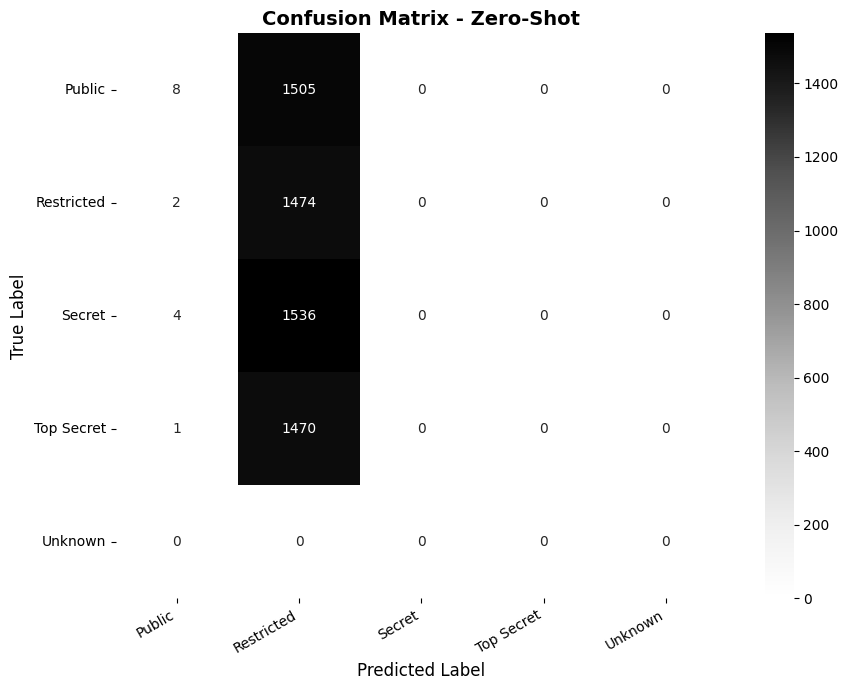

[INFO] Confusion matrix saved to: /content/drive/MyDrive/llama_ndmo_classifier/baseline_results_separate/confusion_matrix_zero_shot.png

[SAVED] Predictions: /content/drive/MyDrive/llama_ndmo_classifier/baseline_results_separate/eval_zero_shot.csv
[SAVED] Summary: /content/drive/MyDrive/llama_ndmo_classifier/baseline_results_separate/eval_zero_shot_summary.csv
[SAVED] Confusion Matrix: /content/drive/MyDrive/llama_ndmo_classifier/baseline_results_separate/confusion_matrix_zero_shot.png


,Experiment,Accuracy,Macro_F1,F1_Public,F1_Restricted,F1_Secret,F1_Top_Secret,Support,Unknown_Predictions
0,Zero-Shot,0.247,0.101398,0.010471,0.395121,0.0,0.0,6000,0


In [ ]:
def build_zero_shot_messages(content):
    """Zero-shot prompt: system instruction only, no examples."""
    system = (
        "أنت خبير إداري متخصص في تصنيف الوثائق العربية بناءً على مستويات حساسية البيانات "
        "حسب مكتب إدارة البيانات الوطنية (NDMO): عام، مقيد، سري، سري للغاية. "
        "مهمتك هي اختيار فئة واحدة فقط. أجب باسم الفئة فقط دون شرح."
    )
    user = (
        "صنف الوثيقة التالية إلى فئة واحدة فقط من الفئات التالية: عام، مقيد، سري، سري للغاية.\n\n"
        f"الوثيقة:\n{content}\n\nالتصنيف:"
    )
    return [{"role": "system", "content": system},
            {"role": "user",   "content": user}]


zero_results, zero_summary = run_experiment(
    experiment_name="Zero-Shot",
    prompt_builder=build_zero_shot_messages,
    save_file=f"{RESULTS_DIR}/eval_zero_shot.csv",
    cm_file=f"{RESULTS_DIR}/confusion_matrix_zero_shot.png"
)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 26.4 MB/s eta 0:00:00


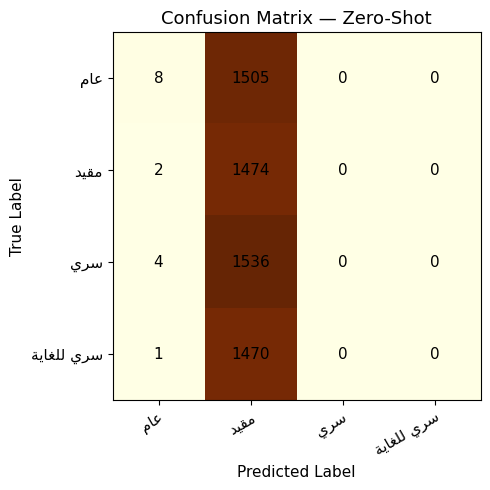

In [6]:
# ── Zero-Shot Confusion Matrix ───────────────────────────
!pip install -q arabic-reshaper python-bidi
import arabic_reshaper
from bidi.algorithm import get_display
import numpy as np # Add numpy import for np.arange

def fix_arabic(text):
    return get_display(arabic_reshaper.reshape(str(text)))

zero_df = pd.read_csv(f"{RESULTS_DIR}/eval_zero_shot.csv")
y_true  = zero_df["Actual"].astype(str).str.strip()
y_pred  = zero_df["Predicted"].astype(str).str.strip()

cm = confusion_matrix(y_true, y_pred, labels=ARABIC_LABELS)
fixed_labels = [fix_arabic(l) for l in ARABIC_LABELS]

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, cmap="YlOrBr")

ax.set_xticks(np.arange(len(fixed_labels)))
ax.set_yticks(np.arange(len(fixed_labels)))
ax.set_xticklabels(fixed_labels, fontsize=11)
ax.set_yticklabels(fixed_labels, fontsize=11)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11)

ax.set_title("Confusion Matrix — Zero-Shot", fontsize=13)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.show()

## 5. One-Shot Evaluation
One labeled example per sensitivity class provided in the prompt.


[STARTING] One-Example-Per-Class


Evaluating One-Example-Per-Class: 100%|██████████| 750/750 [22:04<00:00,  1.77s/it]



[INFO] Completed samples: 6000
[INFO] Prediction distribution:
Predicted
مقيد    5992
عام        8
Name: count, dtype: int64

[SUMMARY] One-Example-Per-Class
Accuracy: 0.2468
Macro F1: 0.1007

[REPORT] Classification Report - One-Example-Per-Class
              precision    recall  f1-score   support

      Public     0.7500    0.0040    0.0079      1513
  Restricted     0.2462    0.9993    0.3950      1476
      Secret     0.0000    0.0000    0.0000      1540
  Top Secret     0.0000    0.0000    0.0000      1471

    accuracy                         0.2468      6000
   macro avg     0.2490    0.2508    0.1007      6000
weighted avg     0.2497    0.2468    0.0992      6000



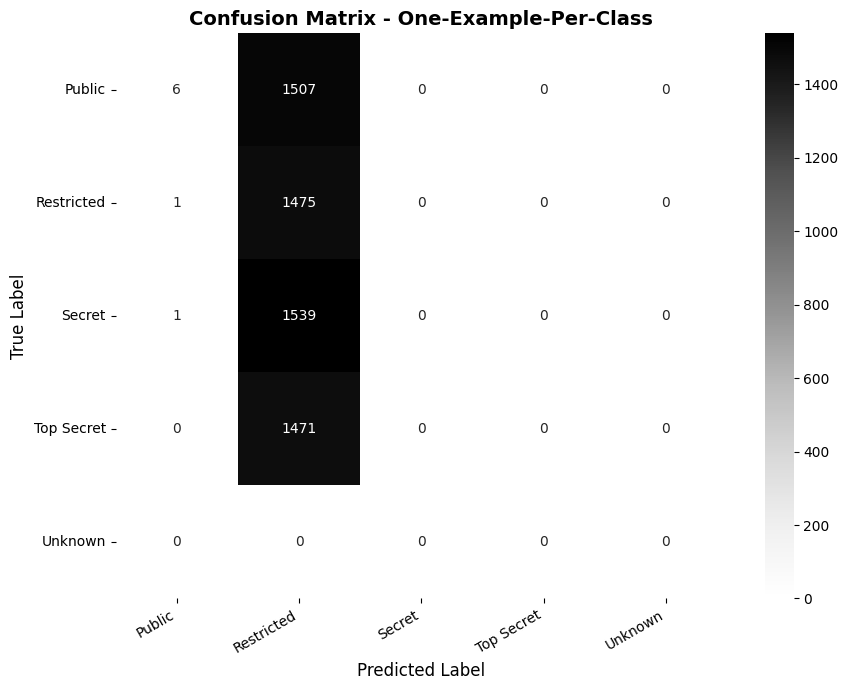

[INFO] Confusion matrix saved to: /content/drive/MyDrive/llama_ndmo_classifier/baseline_results_separate/confusion_matrix_one_example_per_class.png

[SAVED] Predictions: /content/drive/MyDrive/llama_ndmo_classifier/baseline_results_separate/eval_one_example_per_class.csv
[SAVED] Summary: /content/drive/MyDrive/llama_ndmo_classifier/baseline_results_separate/eval_one_example_per_class_summary.csv
[SAVED] Confusion Matrix: /content/drive/MyDrive/llama_ndmo_classifier/baseline_results_separate/confusion_matrix_one_example_per_class.png


,Experiment,Accuracy,Macro_F1,F1_Public,F1_Restricted,F1_Secret,F1_Top_Secret,Support,Unknown_Predictions
0,One-Example-Per-Class,0.246833,0.100727,0.00789,0.395019,0.0,0.0,6000,0


In [ ]:
def build_one_shot_messages(content):
    """One-shot prompt: one labeled example per sensitivity class."""
    system = (
        "أنت خبير إداري متخصص في تصنيف الوثائق العربية بناءً على مستويات حساسية البيانات "
        "حسب مكتب إدارة البيانات الوطنية (NDMO): عام، مقيد، سري، سري للغاية. "
        "مهمتك هي اختيار فئة واحدة فقط. أجب باسم الفئة فقط دون شرح."
    )
    user = f"""
أمثلة توضيحية:

الوثيقة: إعلان عن موعد إقامة حفل المعايدة السنوي لموظفي القطاع.
التصنيف: عام

الوثيقة: محضر اجتماع داخلي يناقش الميزانية التقديرية لإدارة الموارد البشرية.
التصنيف: مقيد

الوثيقة: تقرير فني يوضح ثغرات أمنية غير معالجة في قواعد البيانات الأساسية.
التصنيف: سري

الوثيقة: خطة استراتيجية عليا تتضمن تحركات أمنية استباقية تمس الأمن الوطني.
التصنيف: سري للغاية

الآن صنف الوثيقة التالية إلى فئة واحدة فقط: عام، مقيد، سري، سري للغاية.

الوثيقة:
{content}

التصنيف:
"""
    return [{"role": "system", "content": system},
            {"role": "user",   "content": user}]


one_results, one_summary = run_experiment(
    experiment_name="One-Shot",
    prompt_builder=build_one_shot_messages,
    save_file=f"{RESULTS_DIR}/eval_one_example_per_class.csv",
    cm_file=f"{RESULTS_DIR}/confusion_matrix_one_shot.png"
)


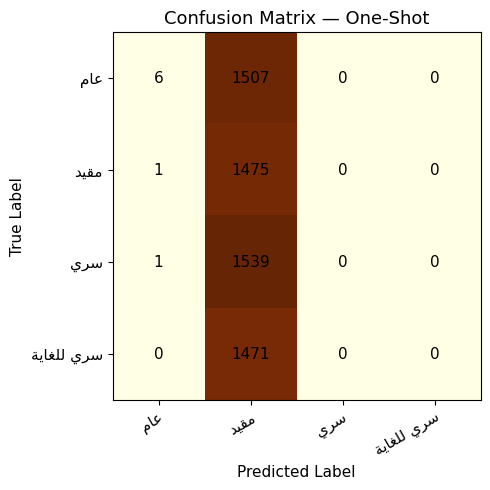

In [7]:
# ── One-Shot Confusion Matrix ────────────────────────────
import arabic_reshaper
from bidi.algorithm import get_display

def fix_arabic(text):
    return get_display(arabic_reshaper.reshape(str(text)))

one_df = pd.read_csv(f"{RESULTS_DIR}/eval_one_example_per_class.csv")
y_true = one_df["Actual"].astype(str).str.strip()
y_pred = one_df["Predicted"].astype(str).str.strip()

cm = confusion_matrix(y_true, y_pred, labels=ARABIC_LABELS)
fixed_labels = [fix_arabic(l) for l in ARABIC_LABELS]

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, cmap="YlOrBr")

ax.set_xticks(np.arange(len(fixed_labels)))
ax.set_yticks(np.arange(len(fixed_labels)))
ax.set_xticklabels(fixed_labels, fontsize=11)
ax.set_yticklabels(fixed_labels, fontsize=11)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11)

ax.set_title("Confusion Matrix — One-Shot", fontsize=13)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.show()


## 6. Three-Shot Evaluation
Three labeled examples per class for richer context.


[STARTING] Three-Examples-Per-Class


Evaluating Three-Examples-Per-Class: 100%|██████████| 750/750 [33:17<00:00,  2.66s/it]



[INFO] Completed samples: 6000
[INFO] Prediction distribution:
Predicted
مقيد    5945
عام       55
Name: count, dtype: int64

[SUMMARY] Three-Examples-Per-Class
Accuracy: 0.2487
Macro F1: 0.1068

[REPORT] Classification Report - Three-Examples-Per-Class
              precision    recall  f1-score   support

      Public     0.4545    0.0165    0.0319      1513
  Restricted     0.2468    0.9939    0.3954      1476
      Secret     0.0000    0.0000    0.0000      1540
  Top Secret     0.0000    0.0000    0.0000      1471

    accuracy                         0.2487      6000
   macro avg     0.1753    0.2526    0.1068      6000
weighted avg     0.1753    0.2487    0.1053      6000



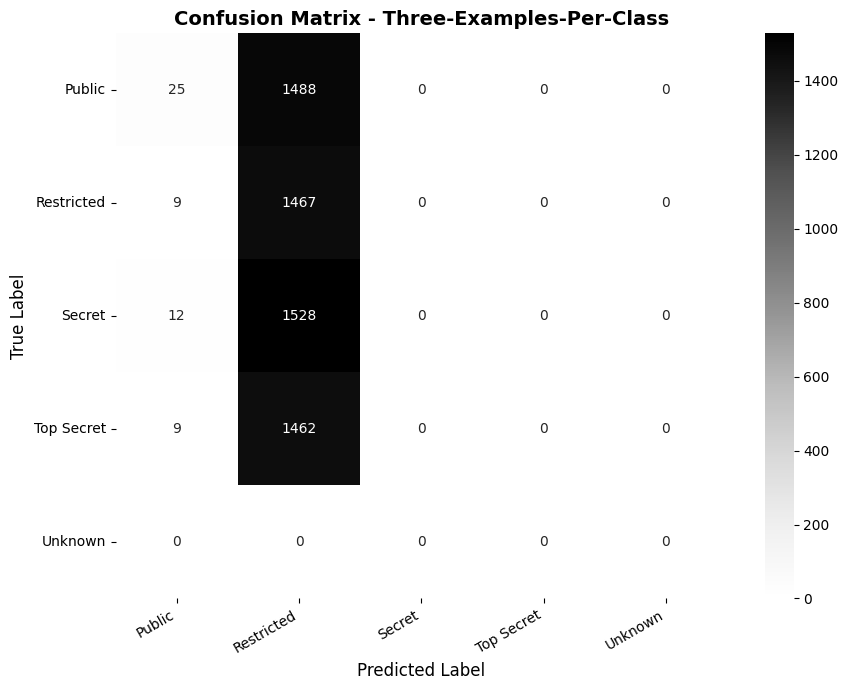

[INFO] Confusion matrix saved to: /content/drive/MyDrive/llama_ndmo_classifier/baseline_results_separate/confusion_matrix_three_examples_per_class.png

[SAVED] Predictions: /content/drive/MyDrive/llama_ndmo_classifier/baseline_results_separate/eval_three_examples_per_class.csv
[SAVED] Summary: /content/drive/MyDrive/llama_ndmo_classifier/baseline_results_separate/eval_three_examples_per_class_summary.csv
[SAVED] Confusion Matrix: /content/drive/MyDrive/llama_ndmo_classifier/baseline_results_separate/confusion_matrix_three_examples_per_class.png


,Experiment,Accuracy,Macro_F1,F1_Public,F1_Restricted,F1_Secret,F1_Top_Secret,Support,Unknown_Predictions
0,Three-Examples-Per-Class,0.248667,0.106813,0.031888,0.395365,0.0,0.0,6000,0


In [ ]:
def build_three_shot_messages(content):
    """Three-shot prompt: three labeled examples per sensitivity class."""
    system = (
        "أنت خبير إداري متخصص في تصنيف الوثائق العربية بناءً على مستويات حساسية البيانات "
        "حسب مكتب إدارة البيانات الوطنية (NDMO): عام، مقيد، سري، سري للغاية. "
        "مهمتك هي اختيار فئة واحدة فقط. أجب باسم الفئة فقط دون شرح."
    )
    user = f"""
أمثلة توضيحية:

الوثيقة: إعلان عن موعد إقامة حفل المعايدة السنوي لموظفي القطاع.
التصنيف: عام
الوثيقة: دليل استخدام البوابة الإلكترونية للموظفين الجدد.
التصنيف: عام
الوثيقة: تقرير إحصائي منشور يوضح أعداد المستفيدين من الخدمات الحكومية.
التصنيف: عام

الوثيقة: محضر اجتماع داخلي يناقش الميزانية التقديرية لإدارة الموارد البشرية.
التصنيف: مقيد
الوثيقة: تعميم داخلي موجه لرؤساء الأقسام بشأن تغييرات في الهيكل التنظيمي.
التصنيف: مقيد
الوثيقة: مسودة مشروع تطويري داخلي لا تزال قيد المراجعة.
التصنيف: مقيد

الوثيقة: تقرير فني يوضح ثغرات أمنية غير معالجة في قواعد البيانات الأساسية.
التصنيف: سري
الوثيقة: تفاصيل العروض المالية والفنية المقدمة من الشركات لمنافسة حكومية قبل الترسية.
التصنيف: سري
الوثيقة: مذكرات قانونية تتعلق بقضايا قائمة ضد المنظمة قد تؤثر على سمعتها.
التصنيف: سري

الوثيقة: خطة استراتيجية عليا تتضمن تحركات أمنية استباقية تمس الأمن الوطني.
التصنيف: سري للغاية
الوثيقة: محضر اجتماع مجلس الوزراء المتعلق بقرارات سيادية عليا.
التصنيف: سري للغاية
الوثيقة: شيفرات التشفير الوطنية أو تفاصيل المواقع العسكرية الحساسة.
التصنيف: سري للغاية

الآن صنف الوثيقة التالية إلى فئة واحدة فقط: عام، مقيد، سري، سري للغاية.

الوثيقة:
{content}

التصنيف:
"""
    return [{"role": "system", "content": system},
            {"role": "user",   "content": user}]


three_results, three_summary = run_experiment(
    experiment_name="Three-Shot",
    prompt_builder=build_three_shot_messages,
    save_file=f"{RESULTS_DIR}/eval_three_examples_per_class.csv",
    cm_file=f"{RESULTS_DIR}/confusion_matrix_three_shot.png"
)


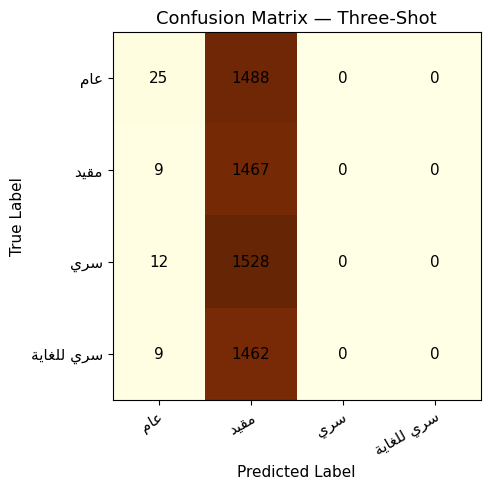

Saved: /content/drive/MyDrive/llama_ndmo_classifier/baseline_results_separate/confusion_matrix_three_shot_arabic.png


In [12]:
three_df = pd.read_csv(f"{RESULTS_DIR}/eval_three_examples_per_class.csv")

plot_confusion_matrix(
    three_df["Actual"].astype(str).str.strip(),
    three_df["Predicted"].astype(str).str.strip(),
    title="Confusion Matrix — Three-Shot",
    save_path=f"{RESULTS_DIR}/confusion_matrix_three_shot_arabic.png"
)